# MD Ficha

## 0) Setup

In [1]:
import re
import pandas as pd
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag, ne_chunk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

print('Setup concluído!')

Setup concluído!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\ferna\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already

## 1) Pré-processamento e Limpeza (Q1.1)

In [ ]:
texto_bruto = """
 RT @user123: I LOVEEEE this product!!! 😍😍 It's amazingg 😱😱
 Check it out at https://example.com #awesome #musthave 
 Can't wait to buy more!!! <3 <3 <3
 """

# <3 -> heart
t = texto_bruto.replace('<3', ' heart ')
# lower
t = t.lower()
# remove urls / mentions / hashtags
t = re.sub(r"http\S+|www\.\S+", "", t)
t = re.sub(r"@\w+", "", t)
t = re.sub(r"#\w+", "", t)
# remove emojis/special chars (keep basic punctuation)
t = re.sub(r"[^a-z0-9\s\.\,\!\?\:\;\'\"\-]", "", t)
# normalize repetitions (2+ -> 1)
t = re.sub(r"(.)\1{1,}", r"\1", t)
# normalize spaces
t = re.sub(r"\s+", " ", t).strip()

t

"rt : i love this product! it's amazing check it out at can't wait to buy more! heart heart heart"

## 2) Tokenização (Q2.1–Q2.3)

In [4]:
texto_complexo = "Dr. Smith went to Washington D.C. on Jan. 15th, 2023. He said: 'Let's meet at 10 a.m. - I'll be there!'"

sentences = sent_tokenize(texto_complexo)
words = word_tokenize(texto_complexo)

print('Sentence tokenization:')
for i,s in enumerate(sentences, 1):
    print(f'{i}. {s}')

print('\nWord tokenization (primeiros 40 tokens):')
print(words[:40])

Sentence tokenization:
1. Dr. Smith went to Washington D.C. on Jan. 15th, 2023.
2. He said: 'Let's meet at 10 a.m. - I'll be there!'

Word tokenization (primeiros 40 tokens):
['Dr.', 'Smith', 'went', 'to', 'Washington', 'D.C.', 'on', 'Jan.', '15th', ',', '2023', '.', 'He', 'said', ':', "'Let", "'s", 'meet', 'at', '10', 'a.m.', '-', 'I', "'ll", 'be', 'there', '!', "'"]


### Questão 2.2
Os principais problemas são:

- Contrações foram partidas: "Let's" virou "'Let" e "'s"; "I'll" virou "I" e "'ll".

- Pontuação aparece como tokens separados (vírgula, ponto final, etc.), o que pode ser chato se eu quiser só palavras limpas.

- Abreviações com ponto podem causar confusão em alguns textos: Dr. / Jan. / D.C. / a.m. têm . e podem ser confundidas com fim de frase ou podem ser separadas de forma estranha noutros casos (dependendo do tokenizer e do contexto).

### Tokenizador regex (exemplo)

In [5]:
token_pattern = r"""
(?:[A-Za-z]\.){2,}
|(?:Dr|Mr|Mrs|Ms|Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)\.
|(?:a\.m\.|p\.m\.)
|\d+(?:st|nd|rd|th)?
|[A-Za-z]+(?:'[A-Za-z]+)?
|[.,!?;:\-]
"""

tokens_custom = re.findall(token_pattern, texto_complexo, flags=re.VERBOSE)
tokens_custom

['Dr.',
 'Smith',
 'went',
 'to',
 'Washington',
 'D.C.',
 'on',
 'Jan.',
 '15th',
 ',',
 '2023',
 '.',
 'He',
 'said',
 ':',
 "Let's",
 'meet',
 'at',
 '10',
 'a.m.',
 '-',
 "I'll",
 'be',
 'there',
 '!']

## 3) Stopwords (Q3.1–Q3.2)

In [6]:
textos = [
 "The book is on the table",
 "To be or not to be, that is the question",
 "The search for the meaning of life is the meaning of life"
]

sw = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text.lower())
    return [tok for tok in tokens if tok.isalpha() and tok not in sw]

limpos_31 = [remove_stopwords(t) for t in textos]
limpos_31

[['book', 'table'],
 ['question'],
 ['search', 'meaning', 'life', 'meaning', 'life']]

In [7]:
def tokens_alpha_lower(text):
    return [t for t in word_tokenize(text.lower()) if t.isalpha()]

docs_tokens = [tokens_alpha_lower(t) for t in textos]
N = len(docs_tokens)

df = Counter()
for toks in docs_tokens:
    df.update(set(toks))

threshold = 0.5
contextual_stop = {w for w, c in df.items() if (c / N) > threshold}

limpos_32 = [[w for w in toks if w not in contextual_stop] for toks in docs_tokens]
limpos_32, contextual_stop

([['book', 'on', 'table'],
  ['to', 'be', 'or', 'not', 'to', 'be', 'that', 'question'],
  ['search', 'for', 'meaning', 'of', 'life', 'meaning', 'of', 'life']],
 {'is', 'the'})

## 4) Stemming vs Lemmatization (Q4.1–Q4.2)

In [8]:
palavras_teste = ['running', 'ran', 'runs', 'better', 'went', 'studies', 'studying', 'cacti', 'cactus']

porter = PorterStemmer()
lemm = WordNetLemmatizer()

stemming = {w: porter.stem(w) for w in palavras_teste}
lemm_default = {w: lemm.lemmatize(w) for w in palavras_teste}
lemm_as_verb = {w: lemm.lemmatize(w, pos='v') for w in palavras_teste}

stemming, lemm_default, lemm_as_verb

({'running': 'run',
  'ran': 'ran',
  'runs': 'run',
  'better': 'better',
  'went': 'went',
  'studies': 'studi',
  'studying': 'studi',
  'cacti': 'cacti',
  'cactus': 'cactu'},
 {'running': 'running',
  'ran': 'ran',
  'runs': 'run',
  'better': 'better',
  'went': 'went',
  'studies': 'study',
  'studying': 'studying',
  'cacti': 'cactus',
  'cactus': 'cactus'},
 {'running': 'run',
  'ran': 'run',
  'runs': 'run',
  'better': 'better',
  'went': 'go',
  'studies': 'study',
  'studying': 'study',
  'cacti': 'cacti',
  'cactus': 'cactus'})

### Questão 4.2 - Comparação
a) Casos onde o stemming é superior

O stemming é superior quando queremos apenas normalizar rapidamente palavras para a mesma raiz, mesmo que não seja uma palavra correta do dicionário.

b) Casos onde a lemmatization é superior

A lemmatization é superior quando queremos obter a forma correta da palavra no dicionário.

c) Casos onde ambos falham ou têm limitações

better → continua better em ambos os casos
Idealmente deveria mapear para good, mas isso exige conhecimento semântico e não apenas morfológico.

cacti → na lemmatization com pos='v' não mudou
Ou seja, sem indicar corretamente o tipo gramatical, pode não funcionar como esperado.

## 5) POS Tagging (Q5.1–Q5.2)

In [9]:
frase = 'They are flying planes to Paris for a conference'

tokens = word_tokenize(frase)
pos_tag(tokens)

[('They', 'PRP'),
 ('are', 'VBP'),
 ('flying', 'VBG'),
 ('planes', 'NNS'),
 ('to', 'TO'),
 ('Paris', 'NNP'),
 ('for', 'IN'),
 ('a', 'DT'),
 ('conference', 'NN')]

### Questão 5.2
A ambiguidade principal está em “flying”, que pode ser interpretado como verbo (eles estão a voar/pilotar aviões) ou como adjetivo que descreve “planes”. O POS tagger escolhe a interpretação mais provável com base em padrões estatísticos, mas não compreende totalmente o significado da frase.

## 6) NER (Q6.1–Q6.4)

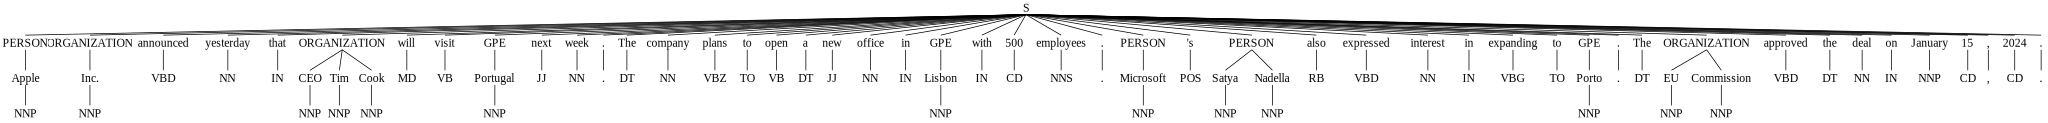

In [11]:
texto_noticia = """
 Apple Inc. announced yesterday that CEO Tim Cook will visit Portugal next week.
 The company plans to open a new office in Lisbon with 500 employees.
 Microsoft's Satya Nadella also expressed interest in expanding to Porto.
 The EU Commission approved the deal on January 15, 2024.
 """

tokens = word_tokenize(texto_noticia)
tags = pos_tag(tokens)
tree = ne_chunk(tags)

tree

In [12]:
def extract_entities(ne_tree):
    entities = []
    for node in ne_tree:
        if hasattr(node, 'label'):
            ent_type = node.label()
            ent_text = ' '.join([leaf[0] for leaf in node.leaves()])
            entities.append((ent_text, ent_type))
    return entities

entities = extract_entities(tree)
entities

[('Apple', 'PERSON'),
 ('Inc.', 'ORGANIZATION'),
 ('CEO Tim Cook', 'ORGANIZATION'),
 ('Portugal', 'GPE'),
 ('Lisbon', 'GPE'),
 ('Microsoft', 'PERSON'),
 ('Satya Nadella', 'PERSON'),
 ('Porto', 'GPE'),
 ('EU Commission', 'ORGANIZATION')]

In [13]:
map_types = {
    'PERSON': 'PESSOA',
    'ORGANIZATION': 'ORGANIZAÇÃO',
    'GPE': 'LOCAL',
    'LOCATION': 'LOCAL'
}

mapped = [(txt, map_types.get(tp, tp)) for txt, tp in entities]

months = r"(January|February|March|April|May|June|July|August|September|October|November|December)"
date_abs_pattern = rf"\b{months}\s+\d{{1,2}},\s+\d{{4}}\b"
date_rel_pattern = r"\b(yesterday|next week|today|tomorrow|last week)\b"

dates_abs_full = [m.group(0) for m in re.finditer(date_abs_pattern, texto_noticia)]
dates_rel = [m.group(0) for m in re.finditer(date_rel_pattern, texto_noticia, flags=re.IGNORECASE)]

final_entities = mapped + [(d, 'DATA') for d in dates_abs_full] + [(d, 'DATA') for d in dates_rel]

import pandas as pd

df_ent = pd.DataFrame(final_entities, columns=['entidade', 'tipo'])
df_freq = df_ent.value_counts(['entidade','tipo']).reset_index(name='frequencia')
df_freq

,entidade,tipo,frequencia
0,Apple,PESSOA,1
1,CEO Tim Cook,ORGANIZAÇÃO,1
2,EU Commission,ORGANIZAÇÃO,1
3,Inc.,ORGANIZAÇÃO,1
4,"January 15, 2024",DATA,1
5,Lisbon,LOCAL,1
6,Microsoft,PESSOA,1
7,Porto,LOCAL,1
8,Portugal,LOCAL,1
9,Satya Nadella,PESSOA,1


### Questão 6.4
Observando os resultados, podemos identificar alguns problemas de classificação:

1. “Apple” classificado como PESSOA

O modelo classificou Apple como PERSON, mas neste contexto deveria ser uma ORGANIZAÇÃO, pois refere-se à empresa Apple Inc.

2. “CEO Tim Cook” classificado como ORGANIZAÇÃO

Esta entidade deveria ser classificada como PESSOA, pois Tim Cook é um indivíduo.
O modelo provavelmente confundiu devido ao prefixo “CEO”.

3. “Microsoft” classificado como PESSOA

Microsoft é uma ORGANIZAÇÃO, mas foi classificado como PERSON.
Isto mostra limitação do modelo estatístico do NLTK.

4. “Inc.” separado de “Apple”

Idealmente deveria ser identificado como “Apple Inc.” (uma única entidade ORGANIZAÇÃO).
O modelo separou em duas entidades distintas.

## 7) BoW e TF‑IDF (Q7.1–Q7.3)

In [14]:
documentos = [
 'the cat sat on the mat',
 'the dog sat on the log',
 'cats and dogs are great pets',
 'the mat is for the cat',
 'dogs love to sit on logs'
]

cv = CountVectorizer()
X_bow = cv.fit_transform(documentos)
bow_df = pd.DataFrame(X_bow.toarray(), columns=cv.get_feature_names_out())

bow_df

,and,are,cat,cats,dog,dogs,for,great,is,log,logs,love,mat,on,pets,sat,sit,the,to
0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,2,0
1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,2,0
2,1,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0
3,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,2,0
4,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1


In [15]:
tfv = TfidfVectorizer()
X_tfidf = tfv.fit_transform(documentos)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfv.get_feature_names_out())

tfidf_df

,and,are,cat,cats,dog,dogs,for,great,is,log,logs,love,mat,on,pets,sat,sit,the,to
0,0.000000,0.000000,0.393895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.393895,0.326968,0.000000,0.393895,0.000000,0.653936,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.452055,0.000000,0.000000,0.000000,0.000000,0.452055,0.000000,0.000000,0.000000,0.302746,0.000000,0.364715,0.000000,0.605492,0.000000
2,0.420669,0.420669,0.000000,0.420669,0.000000,0.339393,0.000000,0.420669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.420669,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.357398,0.000000,0.000000,0.000000,0.442986,0.000000,0.442986,0.000000,0.000000,0.000000,0.357398,0.000000,0.000000,0.000000,0.000000,0.593346,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.357274,0.000000,0.000000,0.000000,0.000000,0.442832,0.442832,0.000000,0.296570,0.000000,0.000000,0.442832,0.000000,0.442832


In [ ]:
terms_bow = list(cv.get_feature_names_out())
terms_tfidf = list(tfv.get_feature_names_out())

cat_bow = X_bow.toarray()[0][terms_bow.index('cat')]
cat_tfidf = X_tfidf.toarray()[0][terms_tfidf.index('cat')]

print('cat (BoW) no doc0 =', cat_bow)
print('cat (TF-IDF) no doc0 =', cat_tfidf)

best_term_doc4 = tfidf_df.iloc[4].idxmax()
print('Maior TF-IDF no doc4 =', best_term_doc4)
print('Valor =', float(tfidf_df.iloc[4].max()))

cat (BoW) no doc0 = 1
cat (TF-IDF) no doc0 = 0.3938946867220082
Maior TF-IDF no doc4 = logs
Valor = 0.4428321995085722


### Questão 7.3
#### Qual método dá mais peso a "cat" no doc 0?

O **Bag-of-Words** dá mais peso a "cat".

- BoW: 1 (contagem direta)
- TF-IDF: 0.394

O BoW usa apenas a frequência da palavra no documento.  
O TF-IDF reduz o peso porque "cat" aparece em mais do que um documento, diminuindo o seu IDF.

---

#### Qual palavra tem maior TF-IDF no doc 4? Porquê?

A palavra com maior TF-IDF no doc 4 é **"logs"** (≈ 0.443).

Isto acontece porque:
- Aparece no documento 4
- É rara no resto do corpus
- Tem um IDF mais elevado

O TF-IDF dá mais peso a palavras que são frequentes no documento, mas raras no conjunto total de documentos.